In [ ]:
!pip install huggingface_hub ipywidgets mediapy loguru einops

In [1]:
from huggingface_hub import login, snapshot_download
import os
HUGGINGFACE_TOKEN = os.environ.get("HUGGINGFACE_TOKEN")
login(token=HUGGINGFACE_TOKEN, add_to_git_credential=True)
model_names = [
        # "Cosmos-0.1-Tokenizer-CI8x8",
        # "Cosmos-0.1-Tokenizer-CI16x16",
        "Cosmos-0.1-Tokenizer-DI8x8",
        "Cosmos-0.1-Tokenizer-DI16x16",
]
for model_name in model_names:
    hf_repo = "nvidia/" + model_name
    local_dir = "/cosmos/checkpoints/" + model_name
    os.makedirs(local_dir, exist_ok=True)
    print(f"downloading {model_name}...")
    snapshot_download(repo_id=hf_repo, local_dir=local_dir)

downloading Cosmos-0.1-Tokenizer-DI8x8...


Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

downloading Cosmos-0.1-Tokenizer-DI16x16...


Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

In [28]:
import cv2
import numpy as np
import torch
import os
import matplotlib.pyplot as plt

In [3]:
!which python

/bin/python


In [4]:
from cosmos_predict1.tokenizer.inference.image_lib import ImageTokenizer
import mediapy as media
from utils import load_all_images

In [5]:
images, image_names, image_paths = load_all_images('/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/assets/original')

Loaded: graph_theory1.png
Loaded: line_chart.png
Loaded: logo1.png
Loaded: logo2.png
Loaded: math_draft1.png
Loaded: menu.jpeg
Loaded: physics1.png
Loaded: physics2.png


In [26]:
from cosmos_predict1.tokenizer.inference.utils import (
    pad_image_batch,
    tensor2numpy,
    numpy2tensor,
    unpad_image_batch,
)

Input tensor shape: torch.Size([1, 3, 2100, 1400])
Indices shape: torch.Size([1, 131, 87])
Discrete codes shape: torch.Size([1, 6, 131, 87])
Number of tokens: 11397
Original image pixels: 2940000
Compression ratio: 257.96x


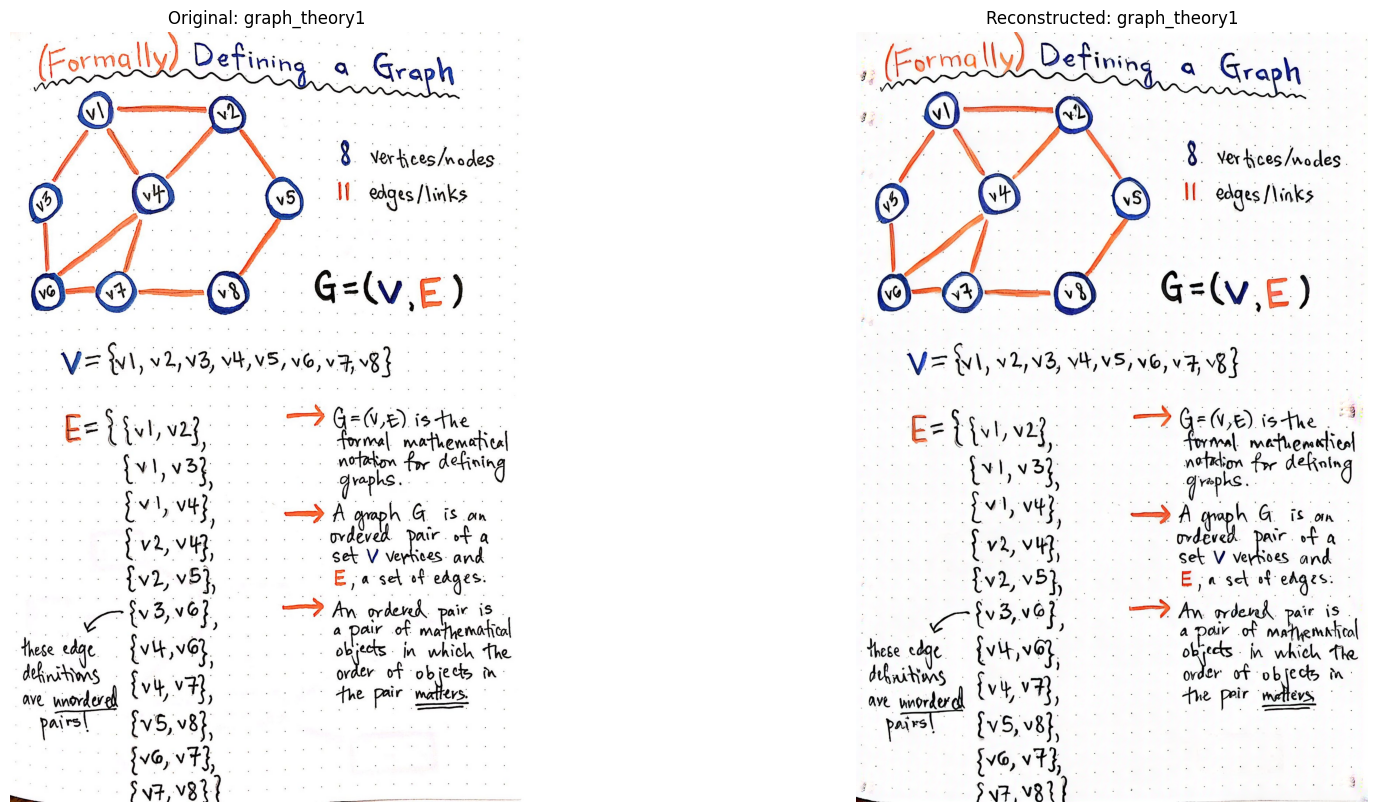

Input tensor shape: torch.Size([1, 3, 626, 712])
Indices shape: torch.Size([1, 39, 44])
Discrete codes shape: torch.Size([1, 6, 39, 44])
Number of tokens: 1716
Original image pixels: 445712
Compression ratio: 259.74x


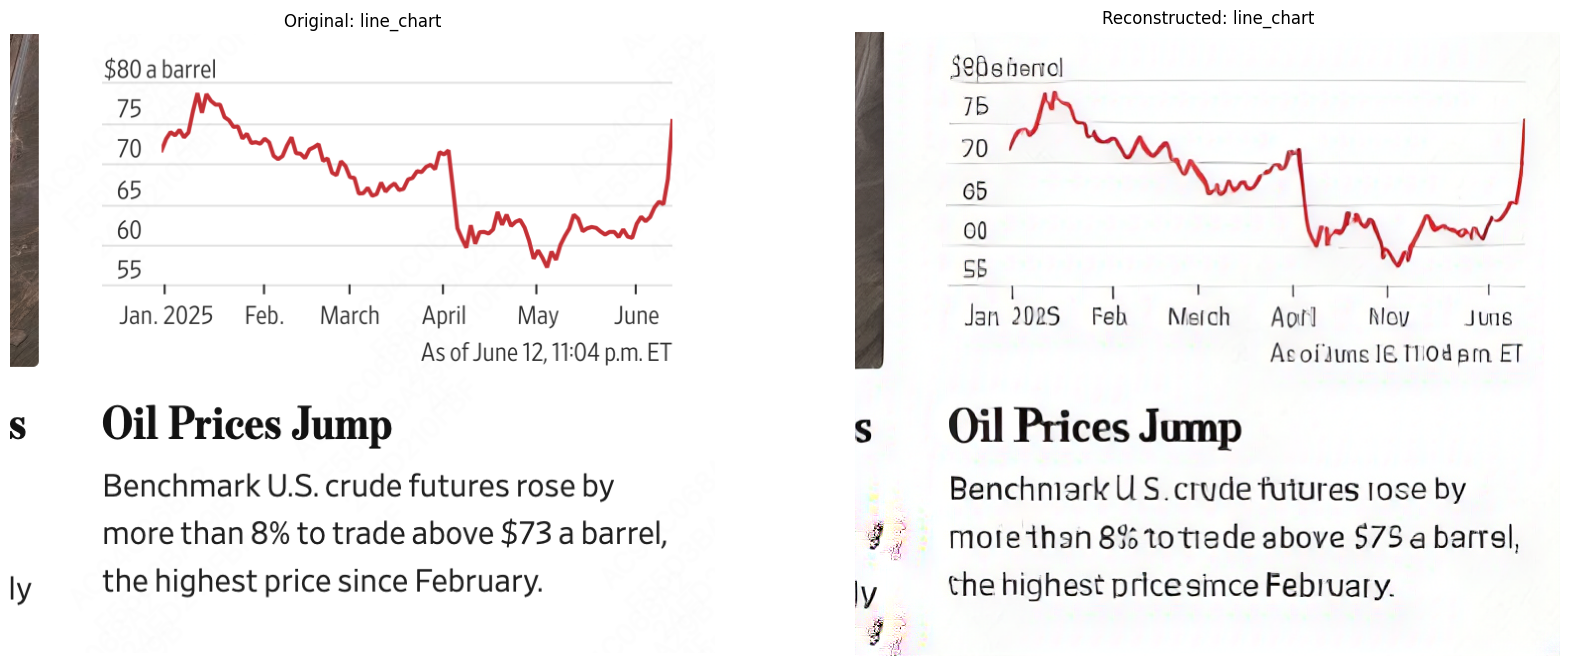

Input tensor shape: torch.Size([1, 3, 935, 800])
Indices shape: torch.Size([1, 58, 50])
Discrete codes shape: torch.Size([1, 6, 58, 50])
Number of tokens: 2900
Original image pixels: 748000
Compression ratio: 257.93x


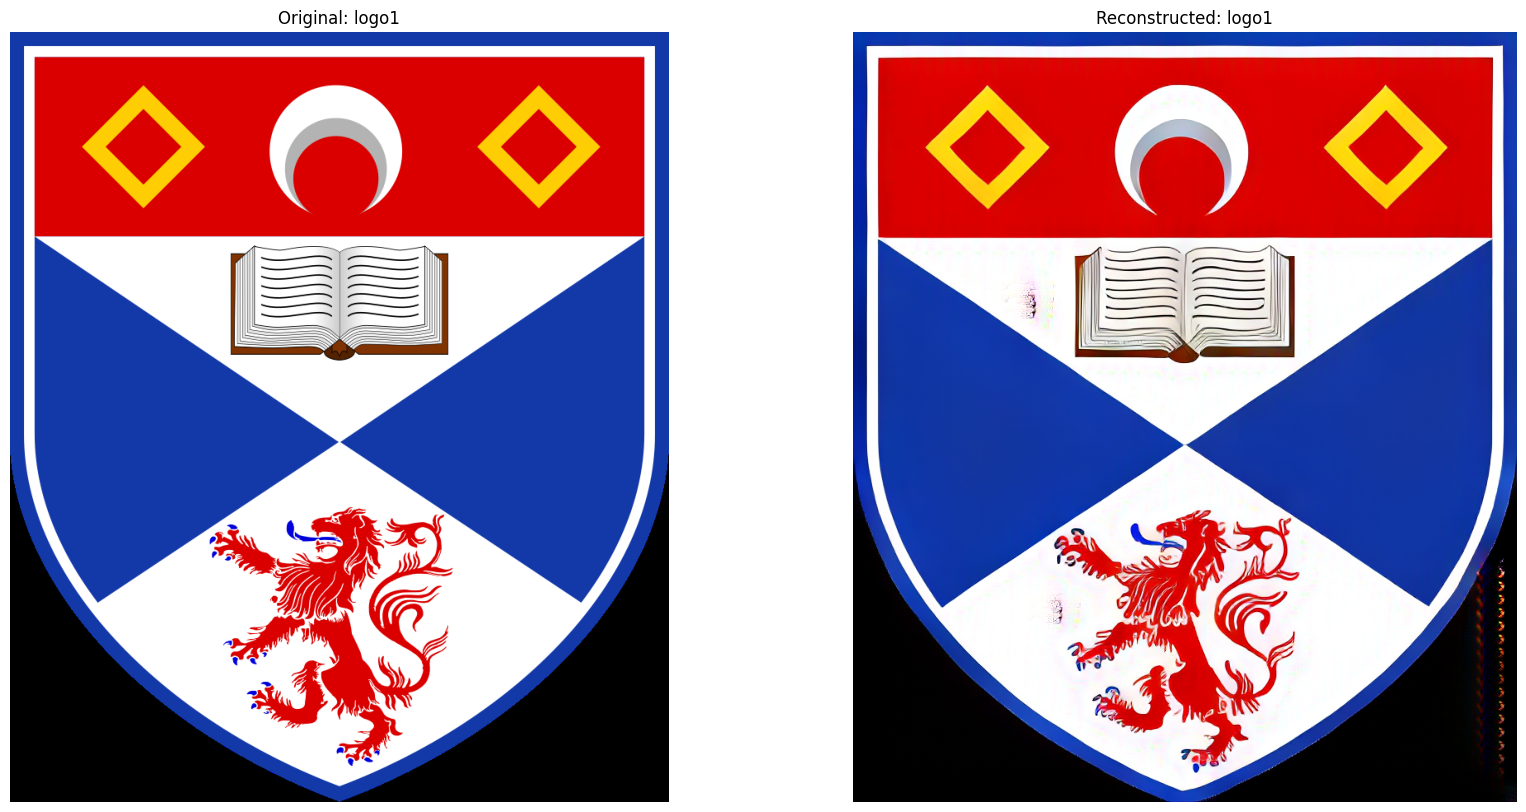

Input tensor shape: torch.Size([1, 3, 586, 555])
Indices shape: torch.Size([1, 36, 34])
Discrete codes shape: torch.Size([1, 6, 36, 34])
Number of tokens: 1224
Original image pixels: 325230
Compression ratio: 265.71x


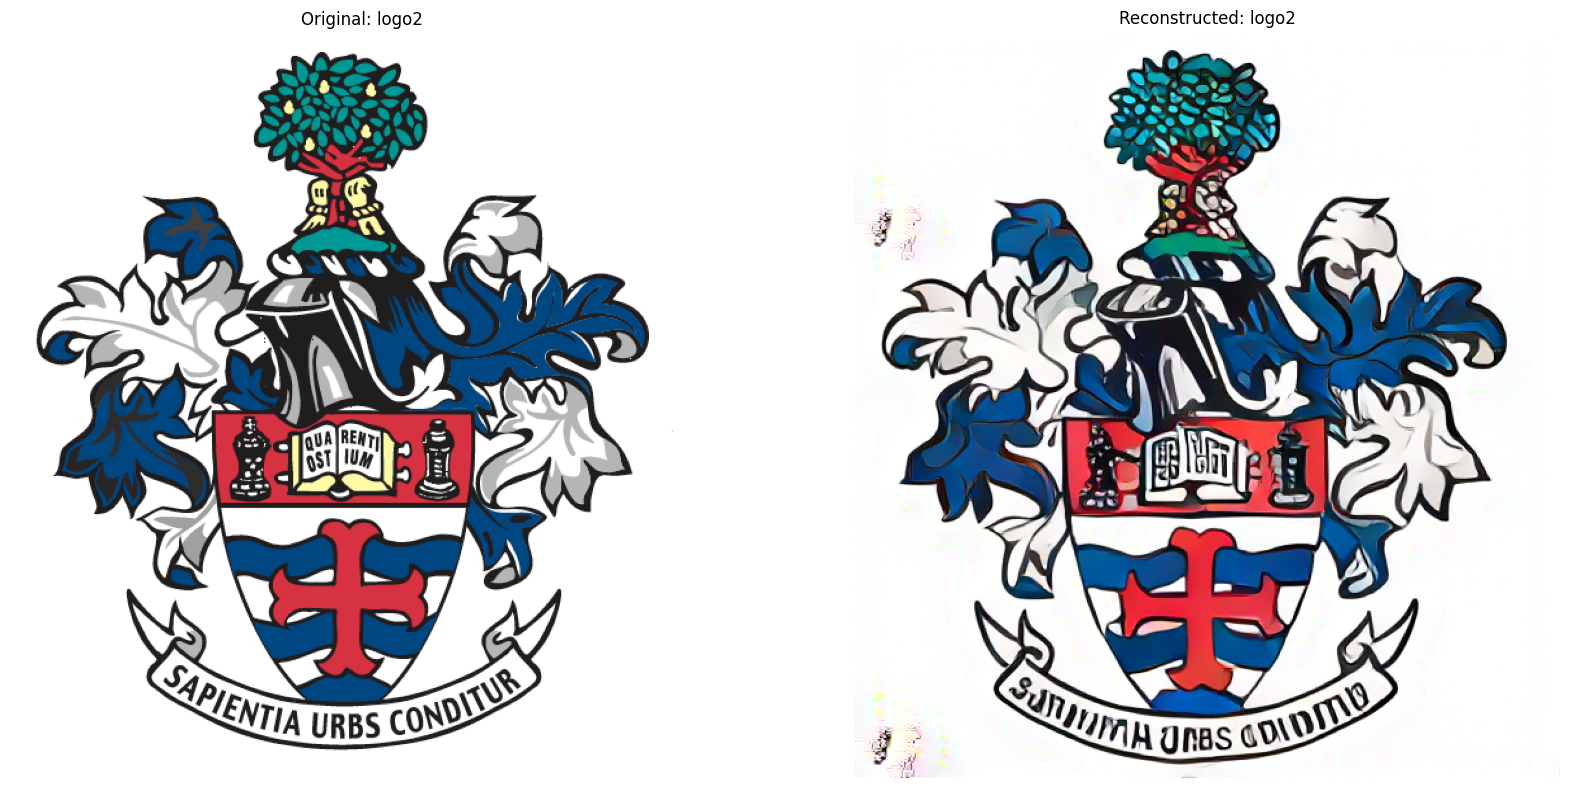

Input tensor shape: torch.Size([1, 3, 864, 934])
Indices shape: torch.Size([1, 54, 58])
Discrete codes shape: torch.Size([1, 6, 54, 58])
Number of tokens: 3132
Original image pixels: 806976
Compression ratio: 257.66x


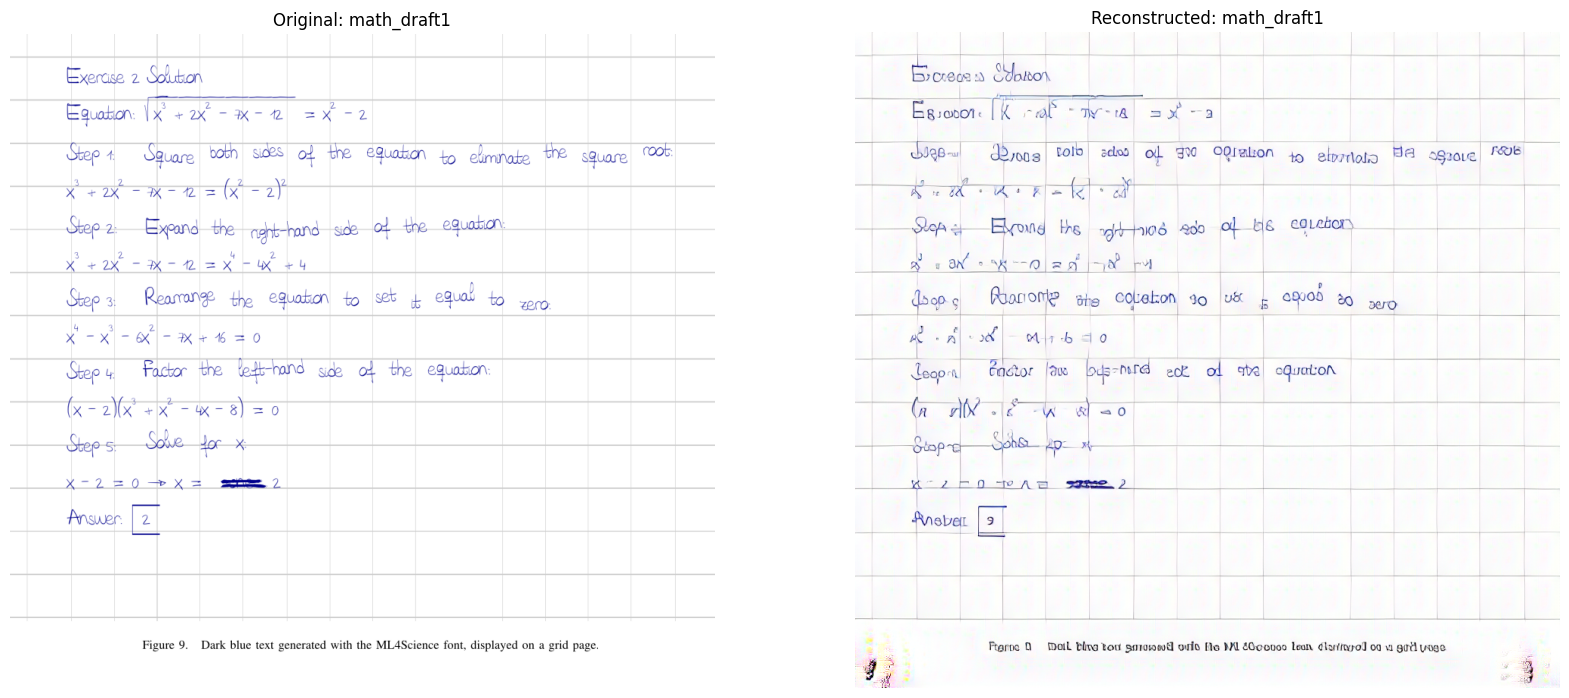

Input tensor shape: torch.Size([1, 3, 2048, 1536])
Indices shape: torch.Size([1, 128, 96])
Discrete codes shape: torch.Size([1, 6, 128, 96])
Number of tokens: 12288
Original image pixels: 3145728
Compression ratio: 256.00x


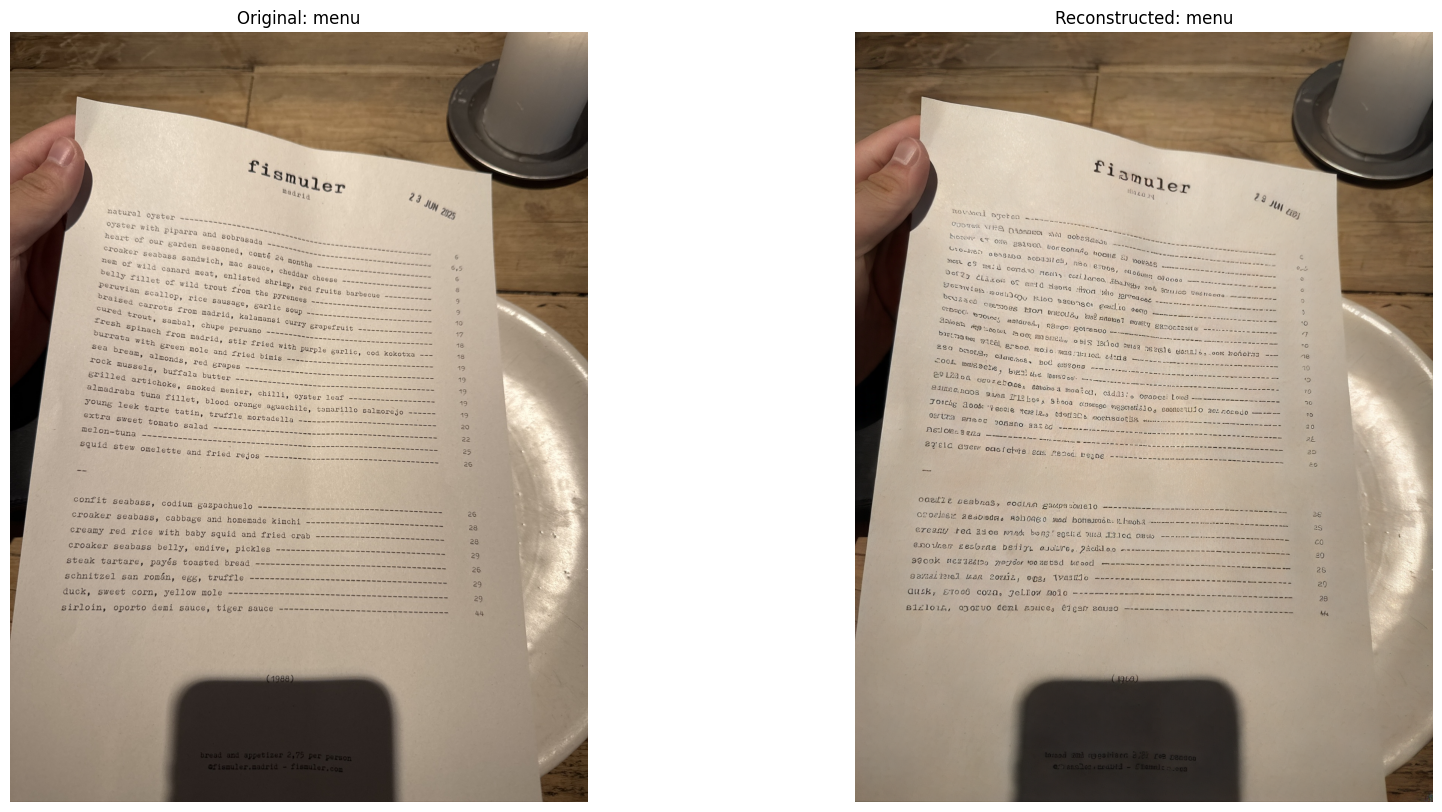

Input tensor shape: torch.Size([1, 3, 270, 527])
Indices shape: torch.Size([1, 17, 33])
Discrete codes shape: torch.Size([1, 6, 17, 33])
Number of tokens: 561
Original image pixels: 142290
Compression ratio: 253.64x


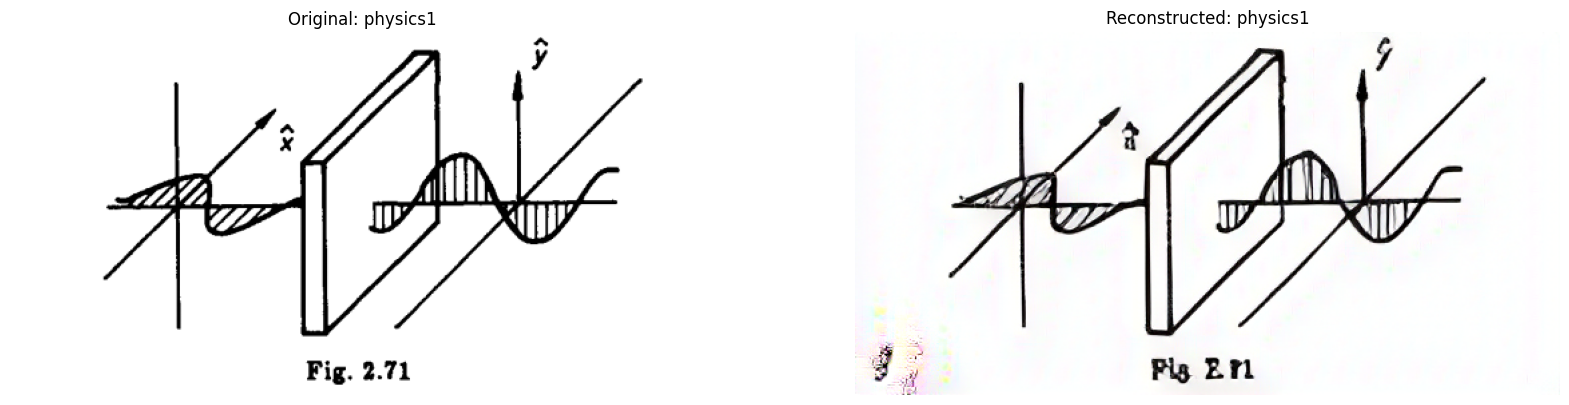

Input tensor shape: torch.Size([1, 3, 341, 651])
Indices shape: torch.Size([1, 21, 40])
Discrete codes shape: torch.Size([1, 6, 21, 40])
Number of tokens: 840
Original image pixels: 221991
Compression ratio: 264.27x


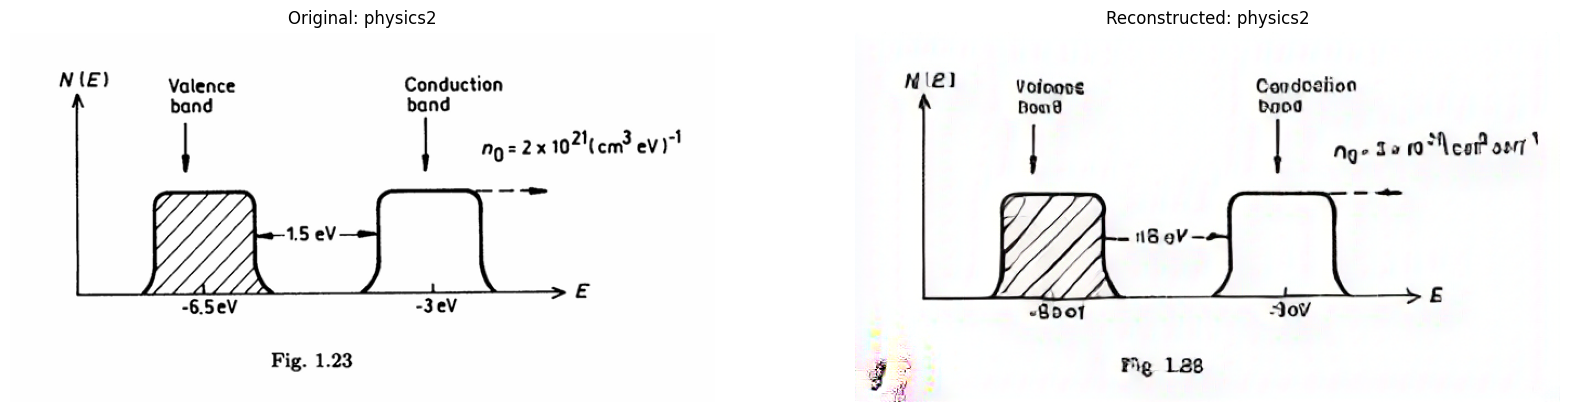

In [33]:
model_name = 'Cosmos-0.1-Tokenizer-DI8x8' # "Cosmos-0.1-Tokenizer-DI8x8", "Cosmos-0.1-Tokenizer-DI16x16"
model_name = 'Cosmos-0.1-Tokenizer-DI16x16'

reconstruction_folder = f"/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/assets/{model_name}"
os.makedirs(reconstruction_folder, exist_ok=True)

encoder_ckpt = f"cosmos/checkpoints/{model_name}/encoder.jit"
decoder_ckpt = f"cosmos/checkpoints/{model_name}/decoder.jit"

tokenizer = ImageTokenizer(
    checkpoint_enc=encoder_ckpt,
    checkpoint_dec=decoder_ckpt,
    device="cuda",
    dtype="bfloat16",
)

for idx, (image, name) in enumerate(zip(images, image_names)):
    if not image.mode == "RGB":
        image = image.convert("RGB")
    input_image = np.array(image)
    assert input_image.ndim == 3 and input_image.shape[2] == 3, "Image must have shape H x W x 3"

    # 4) Expand dimensions to B x H x W x C, since the ImageTokenizer expects a batch dimension
    #    in the input. (Batch size = 1 in this example.) Convert to tensor without padding
    batched_input_image = np.expand_dims(input_image, axis=0) 
    input_tensor = numpy2tensor(batched_input_image, dtype=tokenizer._dtype, device=tokenizer._device)
    print(f"Input tensor shape: {input_tensor.shape}")
    
    # Encode to get latent tokens
    encoded_output = tokenizer.encode(input_tensor)

    indices = encoded_output[0]  # The discrete indices
    discrete_codes = encoded_output[1]

    print(f"Indices shape: {indices.shape}")
    print(f"Discrete codes shape: {discrete_codes.shape}")

    # Calculate number of tokens
    num_tokens = indices.numel() // indices.shape[0]  # tokens per image
    print(f"Number of tokens: {num_tokens}")

    # Calculate compression ratio
    original_pixels = input_tensor.shape[-2] * input_tensor.shape[-1]
    compression_ratio = original_pixels / num_tokens
    print(f"Original image pixels: {original_pixels}")
    print(f"Compression ratio: {compression_ratio:.2f}x")

    # Decode using the indices
    reconstructed_tensor = tokenizer.decode(indices)


   # Convert back to numpy for visualization
    reconstructed_image = tensor2numpy(reconstructed_tensor)[0]  # Remove batch dimension
    
    # Visualize
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
    ax1.imshow(input_image)
    ax1.set_title(f"Original: {name}")
    ax1.axis('off')
    ax2.imshow(reconstructed_image.astype(np.uint8))
    ax2.set_title(f"Reconstructed: {name}")
    ax2.axis('off')
    plt.show()
    
    # Save reconstructed image
    Image.fromarray(reconstructed_image.astype(np.uint8)).save(f"{reconstruction_folder}/{name}_{num_tokens}.png")